# **演習 (回答)**

# **Neural Networks** **ニューラルネットワーク入門**

<img src="https://upload.wikimedia.org/wikipedia/commons/3/3d/Neural_network.svg">


今回の演習では、NANDゲートを中心にニューラルネットワークを構築していきます。

NANDゲートとは、「入力が両方1のときだけ出力が0、それ以外は1」となる論理回路です。
しかし、NANDゲートはシンプルな1層のニューラルネットワーク（パーセプトロン）だけでは表現できず、パーセプトロンアルゴリズムでも学習することができません。

そこで実際のディープラーニングと同じように、**多層ニューラルネットワーク（Multilayer Neural Network）と、その学習に使われる確率的勾配降下法（Stochastic Gradient Descent, SGD）**というアルゴリズムを使い、NANDゲートの学習を実現してみましょう！






## **参考**

ニューラルネットワークについてさらに理解を深めたい方のために、以下の**リソース**をおすすめします：

https://jalammar.github.io/visual-interactive-guide-basics-neural-networks/　（英語）

https://chokkan.github.io/deeplearning/demo-slp.html （ビジュアルdemo）

https://chokkan.github.io/mlnote/classification/03nn.html　（日本語）

# ライブラリのインポート

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier

#### **NANDゲートをシンプルなニューラルネットワークで表現してみよう**

NANDゲートがこのニューラルネットワークで正しく表現できるかどうか、実際に計算して確かめてみましょう！

In [ ]:
# 入力パターン（x1, x2）
x = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# 隠れ層の重み（2つの隠れユニット、それぞれx1, x2の符号を反転して見る）
w_xh = np.array([
    [1, -1],
    [1, -1]
])

# 隠れ層のバイアス
b_xh = np.array([-0.5, 1.5])

# 出力層への重み（2つの隠れユニットから出力へ）
w_hy = np.array([
    1,
    1
])

# 出力層のバイアス
b_hy = np.array([-1.5])

# ーー隠れ層の出力のための計算式を書いてくださいーー
h = np.heaviside(x @ w_xh + b_xh, 0)
print("隠れ層の出力:\n", h)

# ーー出力層の出力のための計算式を書いてくださいーー
y = np.heaviside(h @ w_hy + b_hy, 0)
print("出力:\n", y)

隠れ層の出力:
 [[0. 1.]
 [1. 1.]
 [1. 1.]
 [1. 0.]]
出力:
 [0. 1. 1. 0.]


#### **確率的勾配降下法（Stochastic Gradient Descent）を用いてNANDを学習しましょう**

ニューラルネットワークの重みを「最適な値」に調整するために、**確率的勾配降下法（SGD: Stochastic Gradient Descent）**というアルゴリズムがよく使われます。

**SGDの仕組み**はとてもシンプルです：

1. まず重みを適当な値で初期化します。

2. 現在の重みでデータを使って予測を計算します。

3. 予測と正解ラベルのズレ（誤差）をもとに、重みを少しずつ修正します。

4. この「予測 → 誤差 → 重み修正」を何度も繰り返すことで、だんだんと誤差が小さくなり、最適な重みへと近づいていきます。

💡 この反復的な「学習」によって、ニューラルネットワークはデータからパターンを自動的に発見できるようになります。


今回のSGDの実装では、**活性化関数**としてシグモイド関数を使います。シグモイド関数の出力は0～1の範囲になっています。活性化関数とは、ニューロンの出力をどのような値にするか決める数式のことで、ネットワークに**非線形な変換**を与える重要な役割を持っています。

In [ ]:
def sigmoid(v):
    return 1.0 / (1 + np.exp(-v))

# NANDゲートの学習データ
x = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])

# ーーNANDの真理値表を完成しましょうーー
y = np.array([1, 1, 1, 0])

# 重みの初期化
w = np.array([0.0, 0.0, 0.0])

eta = 0.5   # 学習率

for t in range(100):
    # ーー予測値を計算しようーー
    y_pred = sigmoid(np.dot(x, w))

    # ーー重みの更新式を完成させようーー
    # w = w - 学習率 * 勾配
    grad = np.dot((y_pred - y), x)
    w -= eta * grad

print("学習後のパラメータ:", w)

学習後のパラメータ: [-4.25676443 -4.25676443  6.57684888]


In [ ]:
for i in range(len(x)):
    # ーー出力層の出力のための計算式を書いてくださいーー
    y_pred = np.heaviside(np.dot(x[i], w), 0)
    print(f"x={x[i][:2]} → 予測={int(y_pred)}, 正解={y[i]}")

x=[0 0] → 予測=1, 正解=1
x=[0 1] → 予測=1, 正解=1
x=[1 0] → 予測=1, 正解=1
x=[1 1] → 予測=0, 正解=0


#### **学習率（eta）の違いが学習に与える影響を調べてみよう**

ニューラルネットワークの学習では、**学習率（eta）**の設定がとても重要です。
学習率が大きすぎると学習が不安定になったり、逆に小さすぎると収束が遅くなることがあります。

ここでは、いくつか異なる学習率を使って、損失（Loss）がどのように変化するかを比較してみます。
実際にグラフを描画して、どの学習率が効率的か・安定しているかを観察してみましょう💪

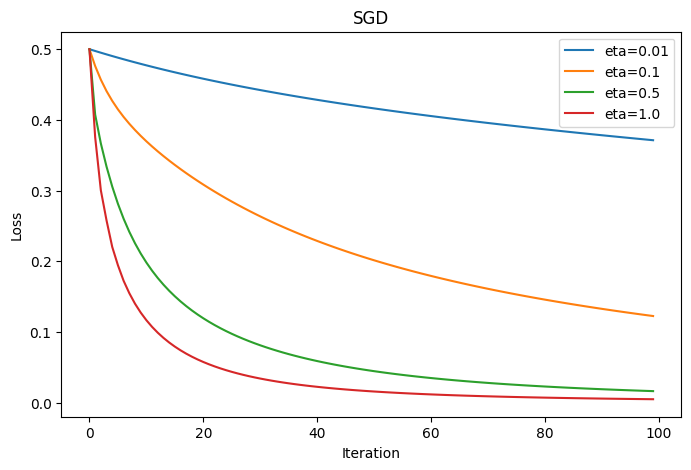

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(v):
    return 1.0 / (1 + np.exp(-v))

def compute_loss(y_pred, y):
    # 2乗誤差
    return 0.5 * np.sum((y_pred - y) ** 2)

x = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])
y = np.array([1, 1, 1, 0])

etas = [0.01, 0.1, 0.5, 1.0]  # いくつかの学習率をリストで用意
loss_histories = []            # 各学習率ごとの損失履歴を保存するリスト

for eta in etas:
    # ーー重みを初期化してくださいーー
    w = np.array([0.0, 0.0, 0.0])
    # この学習率での損失の履歴を保存
    loss_list = []
    for t in range(100):
        # ーーシグモイド関数を使って予測値を計算する式を書いてくださいーー
        y_pred = sigmoid(np.dot(x, w))
        # ーー上で定義された関数を使って損失を計算してみようーー
        loss = compute_loss(y_pred, y)
        # ーー上で計算したLossを損失履歴に追加してくださいーー
        loss_list.append(loss)
        # 勾配を計算
        grad = np.dot((y_pred - y), x)
        # ーー重みの更新式を完成させようーー
        w -= eta * grad
    # この学習率での損失履歴を全体に追加
    loss_histories.append(loss_list)

# グラフで比較
plt.figure(figsize=(8,5))
for i, eta in enumerate(etas):
    plt.plot(loss_histories[i], label=f"eta={eta}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("SGD")
plt.legend()
plt.show()


最後に、グラフを見て、学習率（eta）による学習の違いや、損失（Loss）がどのように変化したかについて、自分なりの考察をまとめてみましょう💪

## **考察**

このグラフは、SGD（確率的勾配降下法）によるNANDゲートの学習において、**異なる学習率（eta）**で損失（Loss）がどのように減少していくかを比較したものです。

1. **学習率（eta）が大きいほど、損失の減少が速い**
- **eta=1.0（赤）**は、他の設定よりも急激に損失が減少していることが分かります。

- **eta=0.5（緑）やeta=0.1（オレンジ）**も、eta=0.01（青）より速く収束しています。

- eta=0.01は、収束が非常に遅く、100回学習してもまだ損失が十分小さくなっていません。


2. **一番良い学習率は？**

  このグラフだけを見ると、**「eta=1.0」が最も急速に損失を下げており効率が良いと考えられます**。ただし、問題やデータセットによっては、学習率が大きすぎると逆に発散して学習がうまく進まない場合があるので、現実のタスクでは適切な値を選ぶために色々試行錯誤することが大事です。

